# TML-BGW Run Analysis (PK-MLM vs Baseline)

This notebook compares **PK-MLM** vs **Baseline** results for runs from **today (the day of running this notebook)** in the W&B project `ideas_cv/tml-bgw`.

### Features:
1. **Date-filtered Analysis**: Focuses on runs created on the current day.
2. **Best-performance Comparison**: Compares the best (minimum) loss and best (maximum) accuracy rather than the last step values by scanning run histories.
3. **Token Length Splits**: Automatically processes and aggregates metrics across three token length splits: `<256`, `256-512`, and `>512` tokens.
4. **Performance vs Learning Rate**: Plots the best metrics against learning rates for both models side-by-side.

In [1]:
import sys
import math
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wandb

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src"))
print("Imports successful!")

Imports successful!


## Helpers for Querying W&B

In [2]:
from datetime import datetime, timezone
# Get today's start date-time in UTC
today_start = datetime.now(timezone.utc).replace(hour=0, minute=0, second=0, microsecond=0)
today_start_str = today_start.strftime("%Y-%m-%dT%H:%M:%SZ") # e.g. "2026-06-02T00:00:00Z"
date_filters = {
    "created_at": {"$gte": today_start_str}
}

key_filters = {
    "$and": [
        {"tags": "finetuning"}
    ]
}

In [3]:
def get_wandb_table(project="ideas_cv/tml-bgw", negative_tags=None,
                    filters=key_filters):
    api = wandb.Api()
    print(f"{filters=}")
    runs = api.runs(path=project,
                    filters=filters)
    
    runs_data = []
    for run in runs:
        run_dict = {
            "sys/id": run.id,
            "sys/name": run.name,
            "sys/state": run.state,
            "sys/tags": run.tags,
            "sys/created_at": run.created_at,
        }
        run_dict.update({f"config/{k}": v for k, v in run.config.items()})
        run_dict.update({f"summary/{k}": v for k, v in run.summary._json_dict.items()})
        runs_data.append(run_dict)
        
    df = pd.DataFrame(runs_data)
    if df.empty:
        return df
        
    if negative_tags:
        if isinstance(negative_tags, str):
            negative_tags = [negative_tags]
        for neg_tag in negative_tags:
            df = df[
                ~df["sys/tags"].apply(
                    lambda x: neg_tag in x if isinstance(x, list) else False
                )
            ]
    return df

def flatten_config_columns(df, sep="/"):
    df = df.copy()
    def walk(prefix, value, out):
        if isinstance(value, dict):
            for k, v in value.items():
                walk(f"{prefix}{sep}{k}", v, out)
        else:
            out[prefix] = value
            
    config_cols = [c for c in df.columns if c.startswith("config/")]
    new_rows = []
    for _, row in df.iterrows():
        flat = {}
        for c in config_cols:
            walk(c, row[c], flat)
        new_rows.append(flat)
        
    flat_df = pd.DataFrame(new_rows, index=df.index)
    df = df.drop(columns=config_cols)
    return pd.concat([df, flat_df], axis=1)

def solve_config_lr(config_lr):
    if pd.isnull(config_lr):
        return np.nan
    try:
        config_lr = float(config_lr)
        if config_lr < 1.0:
            return config_lr
        else:
            return 2.0**(-config_lr)
    except Exception:
        return config_lr

## Query and Filter Runs from the Day of Running

In [4]:
# 1. Fetch runs from ideas_cv/tml-bgw
df_raw = get_wandb_table(project="ideas_cv/tml-bgw")
print(f"Total runs in project: {len(df_raw)}")

# today_str = datetime.now(timezone.utc).strftime("%Y-%m-%d")
# df_today = df_raw[df_raw["sys/created_at"].str.startswith(today_str)].copy()
# # print(f"Runs created today ({today_str}): {len(df_today)}")

# if len(df_today) == 0:
#     print("WARNING: No runs found from today. Falling back to all runs in project for demonstration.")
#     df_filtered = df_raw.copy()
# else:
#     df_filtered = df_today

# Flatten and clean config columns
df_clean = flatten_config_columns(df_raw)
print(f"Cleaned DataFrame shape: {df_clean.shape}")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


filters={'$and': [{'tags': 'finetuning'}]}
Total runs in project: 18
Cleaned DataFrame shape: (18, 1412)


## Extract BEST Metric Values by Scanning Run Histories

In [5]:
api = wandb.Api()
metrics = [
    "steps/eval/loss_(0-256)", "steps/eval/accuracy_(0-256)",
    "steps/eval/loss_(256-512)", "steps/eval/accuracy_(256-512)",
    "steps/eval/loss_(512-inf)", "steps/eval/accuracy_(512-inf)"
]

rows = []
for idx, row in df_clean.iterrows():
    run_id = row["sys/id"]
    run_name = row["sys/name"]
    created_at = row["sys/created_at"]
    
    # Determine model type from name
    name_lower = str(run_name).lower()
    if "baseline" in name_lower:
        model_type = "Baseline"
    else:
        model_type = "PK-MLM"
        
    # Learning rate extraction with fallbacks
    lr = row.get("config/trainer/learning_rate", np.nan)
    if pd.isnull(lr):
        lr = row.get("config/learning_rate", np.nan)
    if pd.isnull(lr):
        lr = row.get("learning_rate", np.nan)
        
    lr = solve_config_lr(lr)
    
    # Fetch history for split metrics
    print(f"Fetching history for run: {run_name}...")
    try:
        run_obj = api.run(f"ideas_cv/tml-bgw/{run_id}")
        history = run_obj.history(keys=metrics, samples=10000)
    except Exception as e:
        print(f"  Failed to fetch history: {e}")
        history = pd.DataFrame()
        
    best_vals = {
        "run_id": run_id,
        "name": run_name,
        "model_type": model_type,
        "learning_rate": lr,
        "created_at": created_at
    }
    
    for m in metrics:
        if not history.empty and m in history.columns:
            series = history[m].dropna()
            if not series.empty:
                best_vals[m] = series.min() if "loss" in m else series.max()
            else:
                best_vals[m] = np.nan
        else:
            # Fallback to summary if history isn't loaded/present
            best_vals[m] = row.get(f"summary/{m}", np.nan)
            
    rows.append(best_vals)

df_results = pd.DataFrame(rows)
df_results

Fetching history for run: baseline-finetunetrainer-split-eval-imdb-lr=0.0002...
Fetching history for run: baseline-finetunetrainer-split-eval-imdb-lr=0.0005...
Fetching history for run: baseline-finetunetrainer-split-eval-imdb-lr=0.002...
Fetching history for run: baseline-finetunetrainer-split-eval-imdb-lr=0.0001...
Fetching history for run: pk_mlm-finetunetrainer-split-eval-imdb-lr=0.0002...
Fetching history for run: pk_mlm-finetunetrainer-split-eval-imdb-lr=0.0005...
Fetching history for run: pk_mlm-finetunetrainer-split-eval-imdb-lr=0.0001...
Fetching history for run: pk_mlm-finetunetrainer-split-eval-imdb-lr=0.002...
Fetching history for run: baseline-finetunetrainer-split-eval-imdb-lr=0.00002...
Fetching history for run: baseline-finetunetrainer-split-eval-imdb-lr=0.00005...
Fetching history for run: pk_mlm-finetunetrainer-split-eval-imdb-lr=0.00002...
Fetching history for run: baseline-finetunetrainer-split-eval-imdb-lr=0.00001...
Fetching history for run: baseline-finetunetrain

,run_id,name,model_type,learning_rate,created_at,steps/eval/loss_(0-256),steps/eval/accuracy_(0-256),steps/eval/loss_(256-512),steps/eval/accuracy_(256-512),steps/eval/loss_(512-inf),steps/eval/accuracy_(512-inf)
0,bm03uvl3,baseline-finetunetrainer-split-eval-imdb-lr=0....,Baseline,0.000200,2026-05-28T21:05:11Z,0.169231,0.9550,0.294427,0.878505,0.292628,0.873670
1,of0qg15j,baseline-finetunetrainer-split-eval-imdb-lr=0....,Baseline,0.000500,2026-05-28T21:05:11Z,0.196863,0.9550,0.292161,0.872079,0.295777,0.875000
2,d3lxecj4,baseline-finetunetrainer-split-eval-imdb-lr=0.002,Baseline,0.002000,2026-05-28T21:10:27Z,0.206074,0.9400,0.321272,0.865070,0.311104,0.872340
3,luawleqy,baseline-finetunetrainer-split-eval-imdb-lr=0....,Baseline,0.000100,2026-05-28T21:10:27Z,0.196476,0.9565,0.276247,0.881425,0.275661,0.890957
4,vbg4b1k5,pk_mlm-finetunetrainer-split-eval-imdb-lr=0.0002,PK-MLM,0.000200,2026-05-28T21:21:22Z,0.195731,0.9390,0.274573,0.881425,0.275119,0.889628
5,a59zfnqg,pk_mlm-finetunetrainer-split-eval-imdb-lr=0.0005,PK-MLM,0.000500,2026-05-28T21:26:40Z,0.188222,0.9480,0.321668,0.870911,0.320192,0.872340
6,dl7fccm5,pk_mlm-finetunetrainer-split-eval-imdb-lr=0.0001,PK-MLM,0.000100,2026-05-28T21:41:41Z,0.163206,0.9480,0.251038,0.908294,0.262103,0.905585
7,v1zt78eq,pk_mlm-finetunetrainer-split-eval-imdb-lr=0.002,PK-MLM,0.002000,2026-05-28T22:44:15Z,0.216872,0.9470,0.313094,0.870327,0.315534,0.885638
8,nksid5ia,baseline-finetunetrainer-split-eval-imdb-lr=0....,Baseline,0.000020,2026-06-02T11:19:34Z,0.160457,0.9480,0.277120,0.881425,0.271197,0.892287
9,vbka8q2x,baseline-finetunetrainer-split-eval-imdb-lr=0....,Baseline,0.000050,2026-06-02T11:24:40Z,0.157079,0.9520,0.275716,0.884346,0.268097,0.885638


## Plot Comparison of Best Metrics per Learning Rate

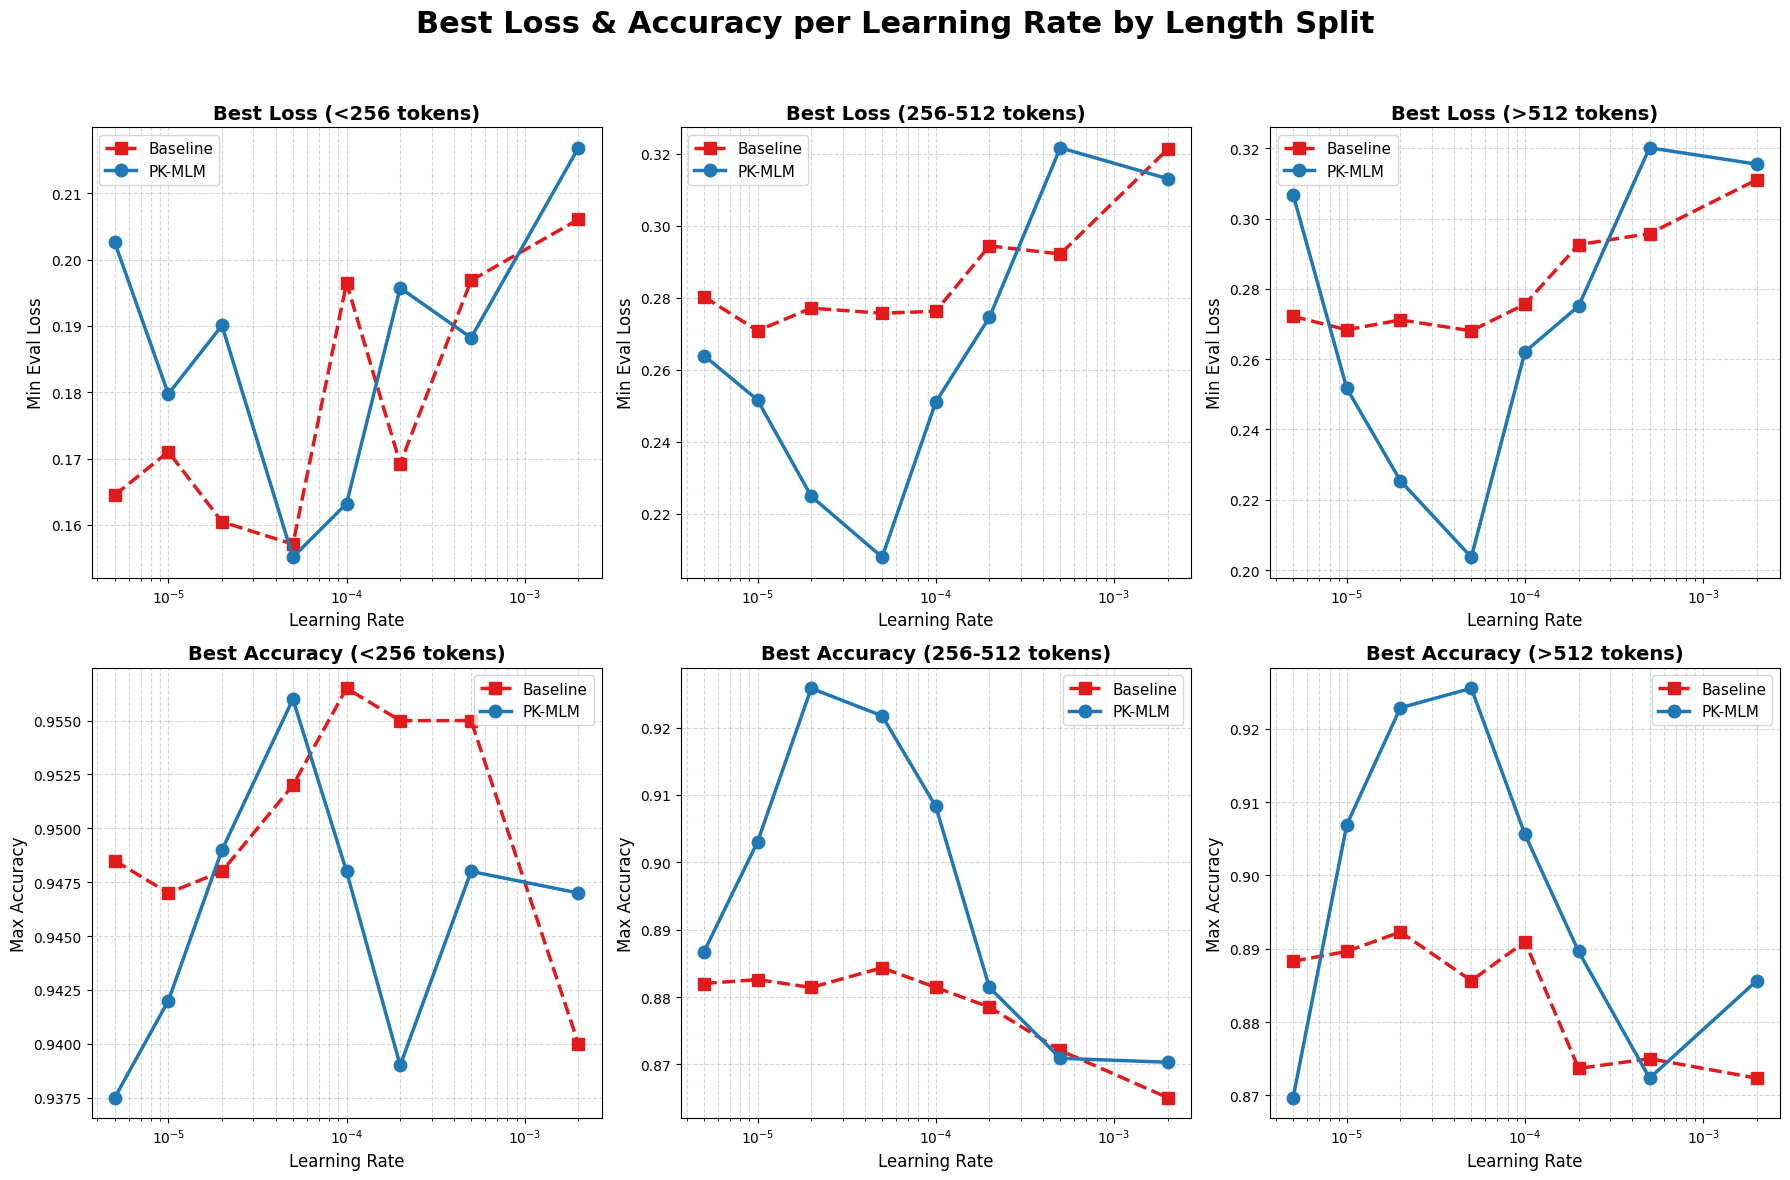

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Best Loss & Accuracy per Learning Rate by Length Split", fontsize=22, fontweight="bold", y=0.98)

splits = [
    ("0-256", "<256 tokens"),
    ("256-512", "256-512 tokens"),
    ("512-inf", ">512 tokens")
]

colors = {"Baseline": "#e31a1c", "PK-MLM": "#1f78b4"}
markers = {"Baseline": "s", "PK-MLM": "o"}
linestyles = {"Baseline": "--", "PK-MLM": "-"}

for col_idx, (split_key, split_label) in enumerate(splits):
    # Row 0: Best Loss
    ax_loss = axes[0, col_idx]
    loss_col = f"steps/eval/loss_({split_key})"
    
    for m_type in ["Baseline", "PK-MLM"]:
        subset = df_results[(df_results["model_type"] == m_type) & df_results[loss_col].notnull()]
        if not subset.empty:
            grouped = subset.sort_values("learning_rate").groupby("learning_rate")[loss_col].mean()
            ax_loss.plot(
                grouped.index,
                grouped.values,
                marker=markers[m_type],
                color=colors[m_type],
                linestyle=linestyles[m_type],
                label=m_type,
                linewidth=2.5,
                markersize=9
            )
    ax_loss.set_title(f"Best Loss ({split_label})", fontsize=14, fontweight="bold")
    ax_loss.set_xlabel("Learning Rate", fontsize=12)
    ax_loss.set_ylabel("Min Eval Loss", fontsize=12)
    ax_loss.set_xscale("log")
    ax_loss.grid(True, which="both", linestyle="--", alpha=0.5)
    ax_loss.legend(fontsize=11)
    
    # Row 1: Best Accuracy
    ax_acc = axes[1, col_idx]
    acc_col = f"steps/eval/accuracy_({split_key})"
    
    for m_type in ["Baseline", "PK-MLM"]:
        subset = df_results[(df_results["model_type"] == m_type) & df_results[acc_col].notnull()]
        if not subset.empty:
            grouped = subset.sort_values("learning_rate").groupby("learning_rate")[acc_col].mean()
            ax_acc.plot(
                grouped.index,
                grouped.values,
                marker=markers[m_type],
                color=colors[m_type],
                linestyle=linestyles[m_type],
                label=m_type,
                linewidth=2.5,
                markersize=9
            )
    ax_acc.set_title(f"Best Accuracy ({split_label})", fontsize=14, fontweight="bold")
    ax_acc.set_xlabel("Learning Rate", fontsize=12)
    ax_acc.set_ylabel("Max Accuracy", fontsize=12)
    ax_acc.set_xscale("log")
    ax_acc.grid(True, which="both", linestyle="--", alpha=0.5)
    ax_acc.legend(fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("best_loss_acc_vs_lr.png", dpi=300, bbox_inches="tight")
plt.show()